In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [2]:
from src.data_loader import get_prices
from src.backtest import run_backtest
import pandas as pd
import numpy as np

In [3]:
tickers = ["AAPL", "TSLA", "SPY"]

prices = get_prices(tickers)

[*********************100%***********************]  3 of 3 completed


In [4]:
portfolio_returns, weights = run_backtest(
    prices.drop(columns=["SPY"]),
    window=60,
    rebalance_freq=21,
    transaction_cost=0.001
)

KeyError: 'SPY'

In [5]:
spy_returns = prices["SPY"].pct_change().dropna()

spy_returns = spy_returns.iloc[-len(portfolio_returns):]

In [6]:
perf = pd.DataFrame({
    "Portfolio": portfolio_returns,
    "SPY": spy_returns.values
})

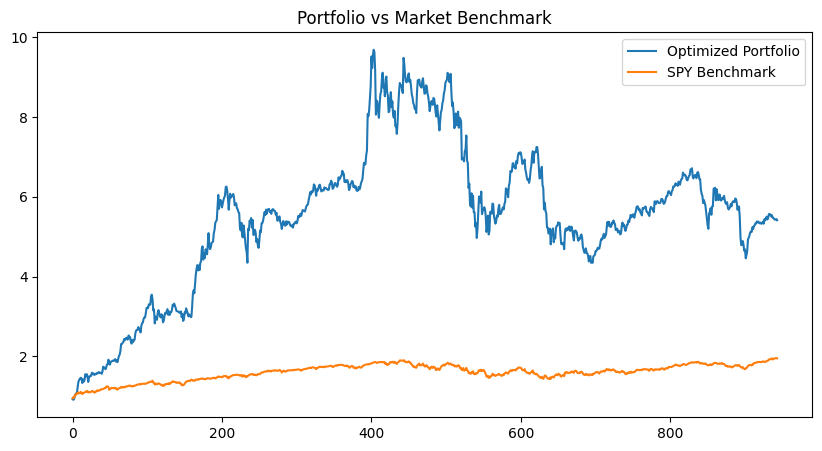

In [7]:
cumulative = (1 + perf).cumprod()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(cumulative["Portfolio"], label="Optimized Portfolio")
plt.plot(cumulative["SPY"], label="SPY Benchmark")

plt.title("Portfolio vs Market Benchmark")
plt.legend()
plt.show()

In [8]:
def sharpe(r):
    return r.mean() / r.std()

def max_drawdown(series):
    cumulative = (1 + series).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    return drawdown.min()

In [9]:
print("PORTFOLIO METRICS")
print("Sharpe:", sharpe(perf["Portfolio"]))
print("Max Drawdown:", max_drawdown(perf["Portfolio"]))

PORTFOLIO METRICS
Sharpe: 0.07513261721554809
Max Drawdown: -0.5512772370544546


In [10]:
print("\nSPY METRICS")
print("Sharpe:", sharpe(perf["SPY"]))
print("Max Drawdown:", max_drawdown(perf["SPY"]))


SPY METRICS
Sharpe: 0.06616775429604416
Max Drawdown: -0.24496392800105746


In [11]:
turnover = weights.diff().abs().sum(axis=1)

print("Average Turnover:", turnover.mean())

Average Turnover: 0.02808637933570221


In [ ]:
gross = portfolio_returns + 0
net = portfolio_returns

print("Sharpe (Net):", net.mean() / net.std())
print("Sharpe (Gross):", gross.mean() / gross.std())

Sharpe (Net): 0.07513261721554809
Sharpe (Gross): 0.07513261721554809
